# 10 — Final Evaluation, Comparison, Interpretation & Saved Model (Stages 13–17)
Produced by `src/final_evaluation.py`, the only module that reads the test split. The final model is chosen by the pre-defined rule *highest mean CV Macro F1*; the test set only measures it.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
FIG = ROOT / 'figures'; REP = ROOT / 'reports'

## Stage 15 — model comparison

In [2]:
pd.read_csv(REP / 'model_comparison.csv', index_col=0)

,CV Macro F1 (mean),CV Macro F1 (std),Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),Test F1 (weighted),Test ROC-AUC (macro OvR),Test ROC-AUC (weighted OvR)
"Baseline (Dummy, most frequent)",0.1969,0.0000,0.9688,0.1938,0.2000,0.1968,0.9535,0.5000,0.5000
Baseline (Logistic Regression),0.7084,0.0419,0.9824,0.7119,0.6134,0.6455,0.9796,0.9890,0.9842
Random Forest,0.7909,0.0129,0.9548,0.7587,0.9122,0.7773,0.9714,0.9908,0.9878
XGBoost,0.7956,0.0294,0.9894,0.7870,0.7713,0.7750,0.9886,0.9873,0.9837
CatBoost,0.7766,0.0304,0.9874,0.7321,0.7145,0.7195,0.9858,0.9878,0.9868
Stacking,0.7881,0.0101,0.9467,0.7778,0.9669,0.8021,0.9678,0.9913,0.9908
Best Model (XGBoost),0.7956,0.0294,0.9894,0.7870,0.7713,0.7750,0.9886,0.9873,0.9837


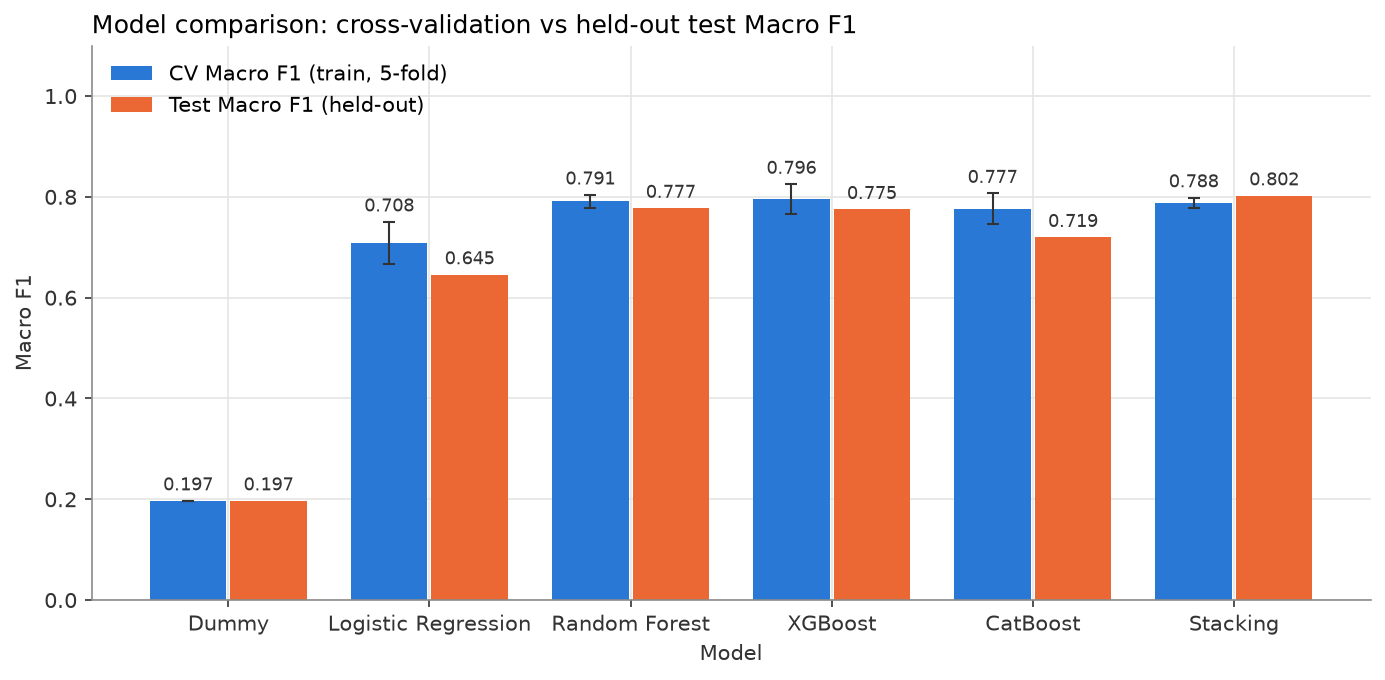

In [3]:
display(Image(filename=str(FIG / '15_model_comparison_macro_f1.png'), width=950))

## Stage 13 — per-class F1, all models

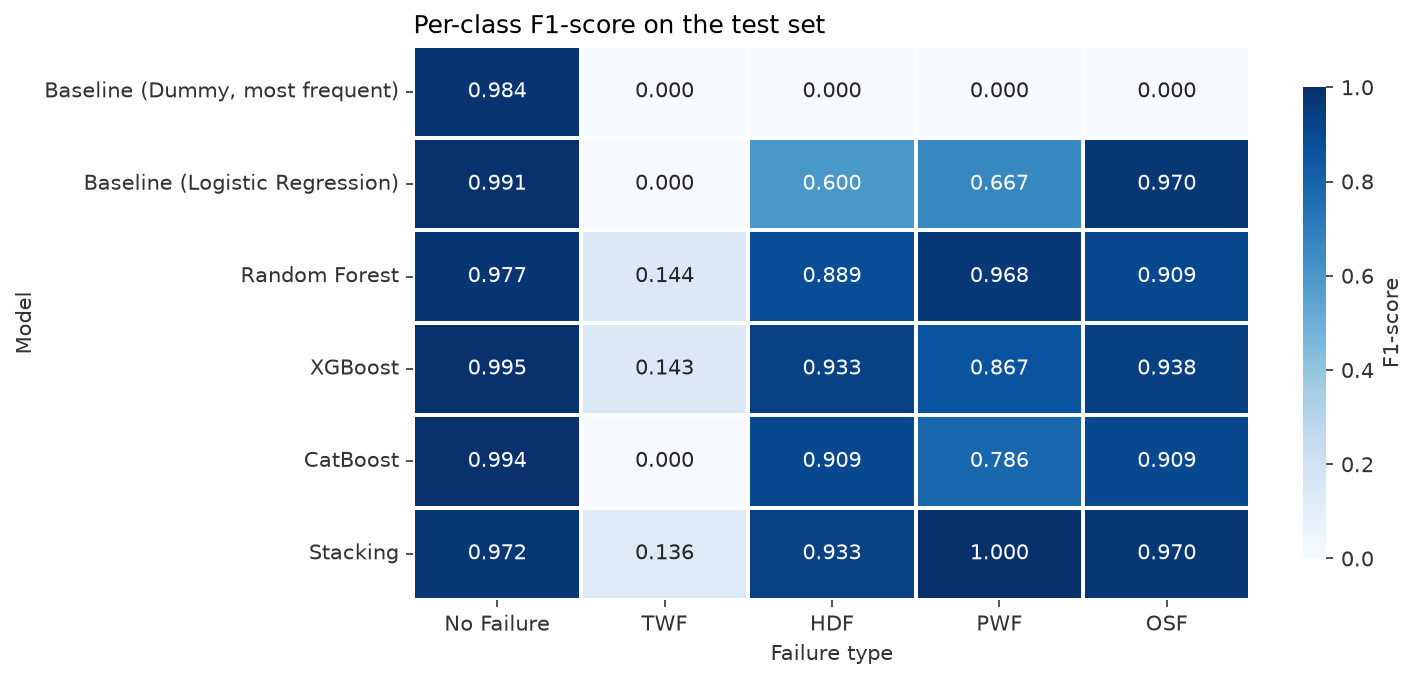

In [4]:
display(Image(filename=str(FIG / '13_per_class_f1_all_models.png'), width=800))

In [5]:
pd.read_csv(REP / 'evaluation/per_class_metrics_all_models.csv')

,model,class,precision,recall,f1,support
0,"Baseline (Dummy, most frequent)",No Failure,0.9688,1.0000,0.9842,1928
1,"Baseline (Dummy, most frequent)",TWF,0.0000,0.0000,0.0000,9
2,"Baseline (Dummy, most frequent)",HDF,0.0000,0.0000,0.0000,21
3,"Baseline (Dummy, most frequent)",PWF,0.0000,0.0000,0.0000,16
4,"Baseline (Dummy, most frequent)",OSF,0.0000,0.0000,0.0000,16
5,Baseline (Logistic Regression),No Failure,0.9866,0.9953,0.9910,1928
6,Baseline (Logistic Regression),TWF,0.0000,0.0000,0.0000,9
7,Baseline (Logistic Regression),HDF,0.6316,0.5714,0.6000,21
8,Baseline (Logistic Regression),PWF,1.0000,0.5000,0.6667,16
9,Baseline (Logistic Regression),OSF,0.9412,1.0000,0.9697,16


## Final model — classification report

In [6]:
print(open(REP / 'classification_report.txt').read())

Final model: XGBoost
Selected by: highest mean 5-fold CV Macro F1 (training split)

              precision    recall  f1-score   support

  No Failure     0.9938    0.9953    0.9946      1928
         TWF     0.2000    0.1111    0.1429         9
         HDF     0.8750    1.0000    0.9333        21
         PWF     0.9286    0.8125    0.8667        16
         OSF     0.9375    0.9375    0.9375        16

    accuracy                         0.9894      1990
   macro avg     0.7870    0.7713    0.7750      1990
weighted avg     0.9880    0.9894    0.9886      1990



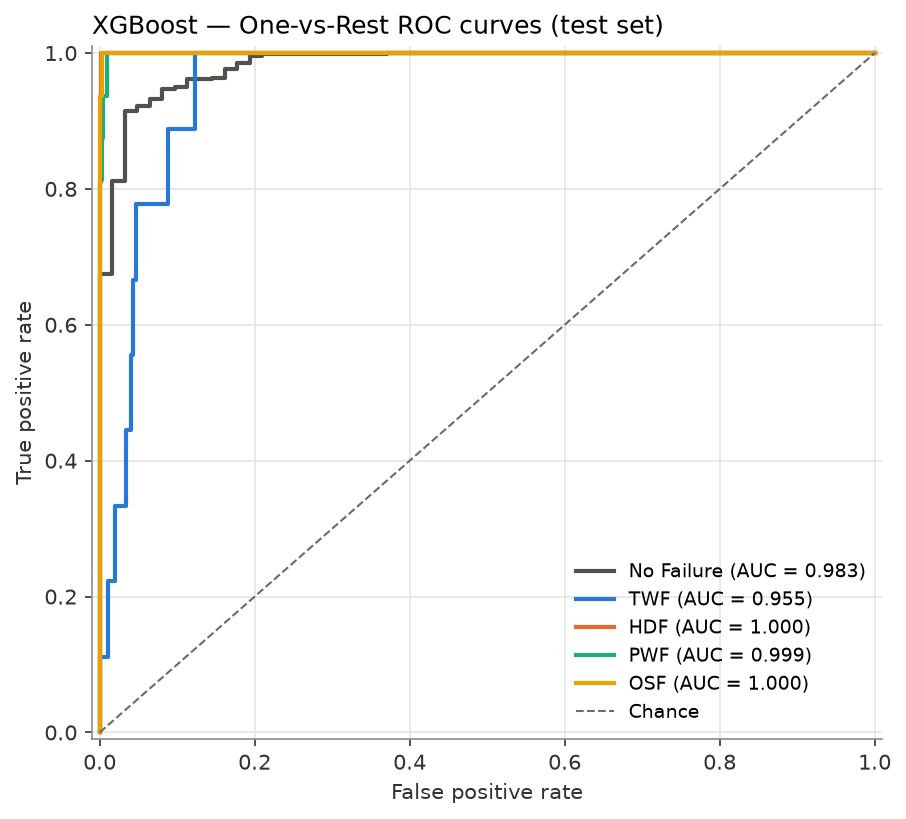

In [7]:
display(Image(filename=str(FIG / '13_roc_curves_final_model.png'), width=600))

## Stage 14 — misclassification analysis

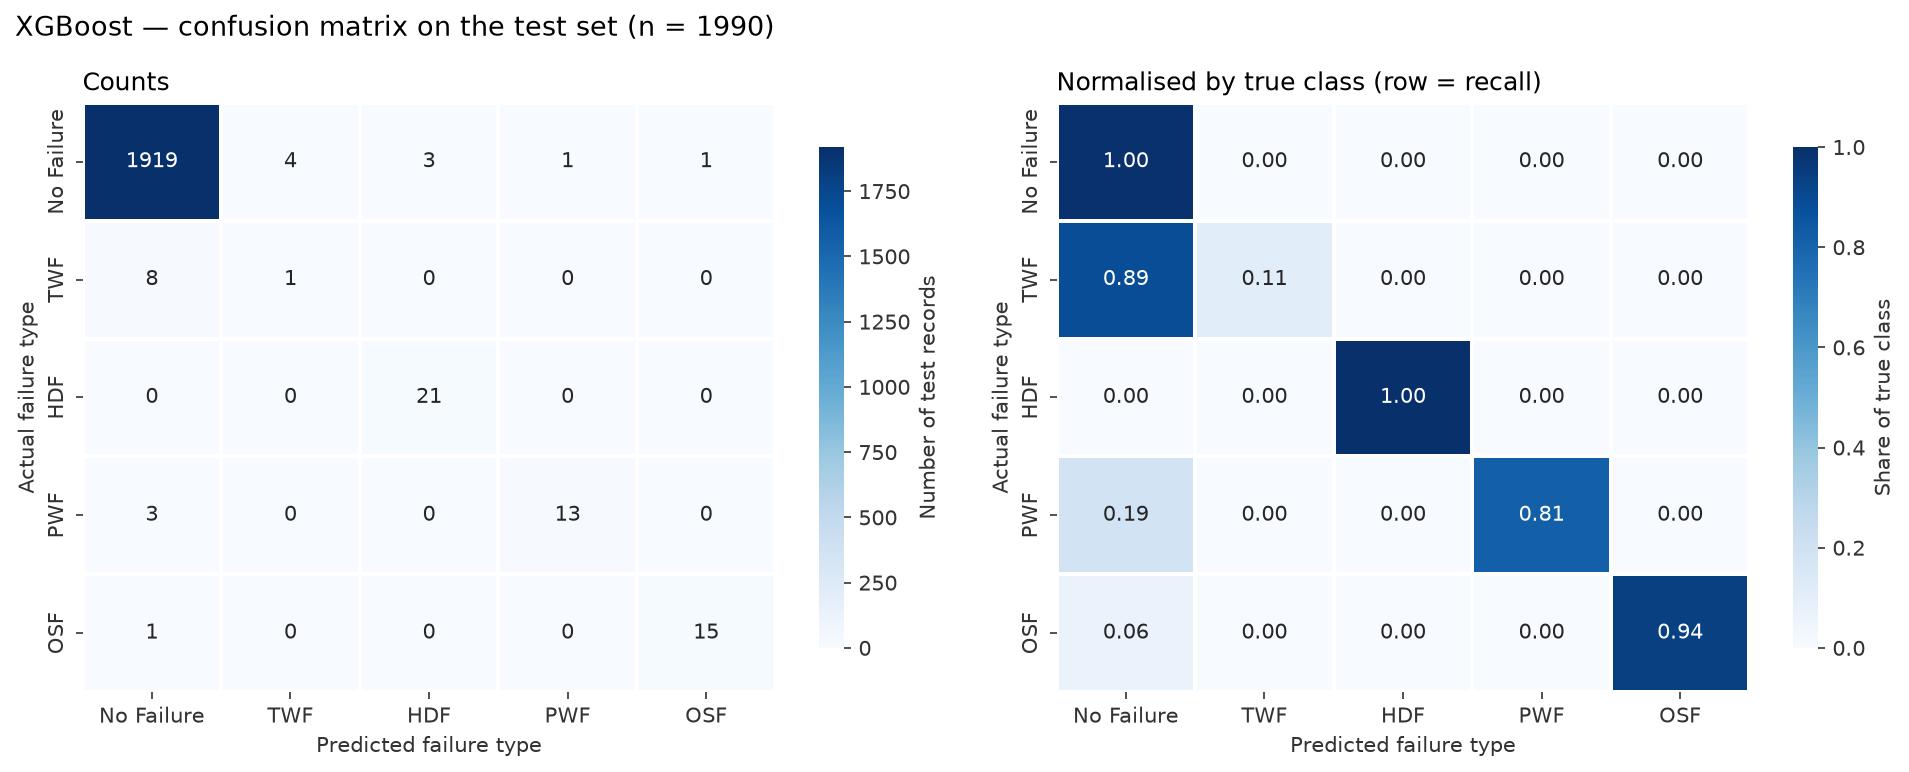

In [8]:
display(Image(filename=str(FIG / '14_confusion_matrix_final_model.png'), width=950))

In [9]:
pd.read_csv(REP / 'evaluation/final_model_confusion_pairs.csv')

,actual,predicted,count,share_of_actual_class_%
0,TWF,No Failure,8,88.9
1,No Failure,TWF,4,0.2
2,No Failure,HDF,3,0.2
3,PWF,No Failure,3,18.8
4,No Failure,PWF,1,0.1
5,No Failure,OSF,1,0.1
6,OSF,No Failure,1,6.2


In [10]:
pd.read_csv(REP / 'evaluation/final_model_per_class.csv')

,class,precision,recall,f1,support,tier
0,No Failure,0.9938,0.9953,0.9946,1928,High
1,TWF,0.2000,0.1111,0.1429,9,Low
2,HDF,0.8750,1.0000,0.9333,21,High
3,PWF,0.9286,0.8125,0.8667,16,High
4,OSF,0.9375,0.9375,0.9375,16,High


In [11]:
pd.read_csv(REP / 'misclassification_analysis.csv')

,actual,predicted,confidence_in_prediction,probability_of_actual_class,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp difference [K],Power [W],Strain [min*Nm]
0,TWF,No Failure,0.9965,0.0034,L,304.4,313.7,1509.0,35.0,205.0,9.3,5530.773867,7175.0
1,No Failure,HDF,0.9871,0.0122,L,302.2,310.8,1350.0,56.6,76.0,8.6,8001.636489,4301.6
2,No Failure,HDF,0.9961,0.0037,L,302.2,310.8,1340.0,47.8,54.0,8.6,6707.509755,2581.2
3,No Failure,OSF,0.7830,0.2073,M,298.1,307.4,1363.0,60.1,187.0,9.3,8578.254876,11238.7
4,TWF,No Failure,0.9973,0.0026,L,298.0,308.5,1429.0,37.7,220.0,10.5,5641.598783,8294.0
5,TWF,No Failure,0.8268,0.1721,L,302.2,311.3,1530.0,37.3,207.0,9.1,5976.251705,7721.1
6,TWF,No Failure,0.9947,0.0052,L,297.4,308.3,1475.0,40.5,222.0,10.9,6255.696371,8991.0
7,No Failure,TWF,0.9376,0.0622,M,297.9,307.4,1610.0,34.6,219.0,9.5,5833.518679,7577.4
8,No Failure,HDF,0.9997,0.0003,M,302.2,310.8,1356.0,48.3,36.0,8.6,6858.599418,1738.8
9,TWF,No Failure,0.9998,0.0002,L,298.8,308.9,1455.0,41.3,208.0,10.1,6292.767165,8590.4


In [12]:
pd.read_csv(REP / 'evaluation/misclassification_feature_profiles.csv')

,pair,group,n,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp difference [K],Power [W],Strain [min*Nm]
0,TWF -> No Failure,misclassified TWF -> No Failure,8,298.65,309.20,1492.0,37.50,207.5,10.7,5808.93,8007.55
1,TWF -> No Failure,correct TWF,1,301.80,309.70,1442.0,45.30,233.0,7.9,6840.57,10554.90
2,TWF -> No Failure,correct No Failure,1919,300.00,310.10,1507.0,40.00,106.0,9.8,6257.05,4022.40
3,No Failure -> TWF,misclassified No Failure -> TWF,4,299.20,308.95,1588.0,35.25,217.0,9.4,5860.40,7450.50
4,No Failure -> TWF,correct No Failure,1919,300.00,310.10,1507.0,40.00,106.0,9.8,6257.05,4022.40
5,No Failure -> TWF,correct TWF,1,301.80,309.70,1442.0,45.30,233.0,7.9,6840.57,10554.90
6,No Failure -> HDF,misclassified No Failure -> HDF,3,302.20,310.80,1350.0,48.30,54.0,8.6,6858.60,2581.20
7,No Failure -> HDF,correct No Failure,1919,300.00,310.10,1507.0,40.00,106.0,9.8,6257.05,4022.40
8,No Failure -> HDF,correct HDF,21,302.40,310.40,1336.0,54.60,110.0,8.3,7783.81,6402.00
9,PWF -> No Failure,misclassified PWF -> No Failure,3,299.00,310.20,1399.0,61.50,92.0,11.1,9012.44,5750.00


## Stage 16 — feature importance & SHAP

In [13]:
pd.read_csv(REP / 'feature_importance.csv')

,input_feature,macro_f1_drop_mean,macro_f1_drop_std,feature,native_importance
0,Torque [Nm],0.37605,0.01238,Type_L,0.00676
1,Rotational speed [rpm],0.34169,0.01787,Type_M,0.01509
2,Tool wear [min],0.21691,0.02229,Type_H,0.10212
3,Air temperature [K],0.18819,0.00852,Air temperature [K],0.03226
4,Process temperature [K],0.15637,0.01024,Process temperature [K],0.01014
5,Type,0.04487,0.01543,Rotational speed [rpm],0.09032
6,NaN,NaN,NaN,Torque [Nm],0.15652
7,NaN,NaN,NaN,Tool wear [min],0.12472
8,NaN,NaN,NaN,Temp difference [K],0.15087
9,NaN,NaN,NaN,Power [W],0.13568


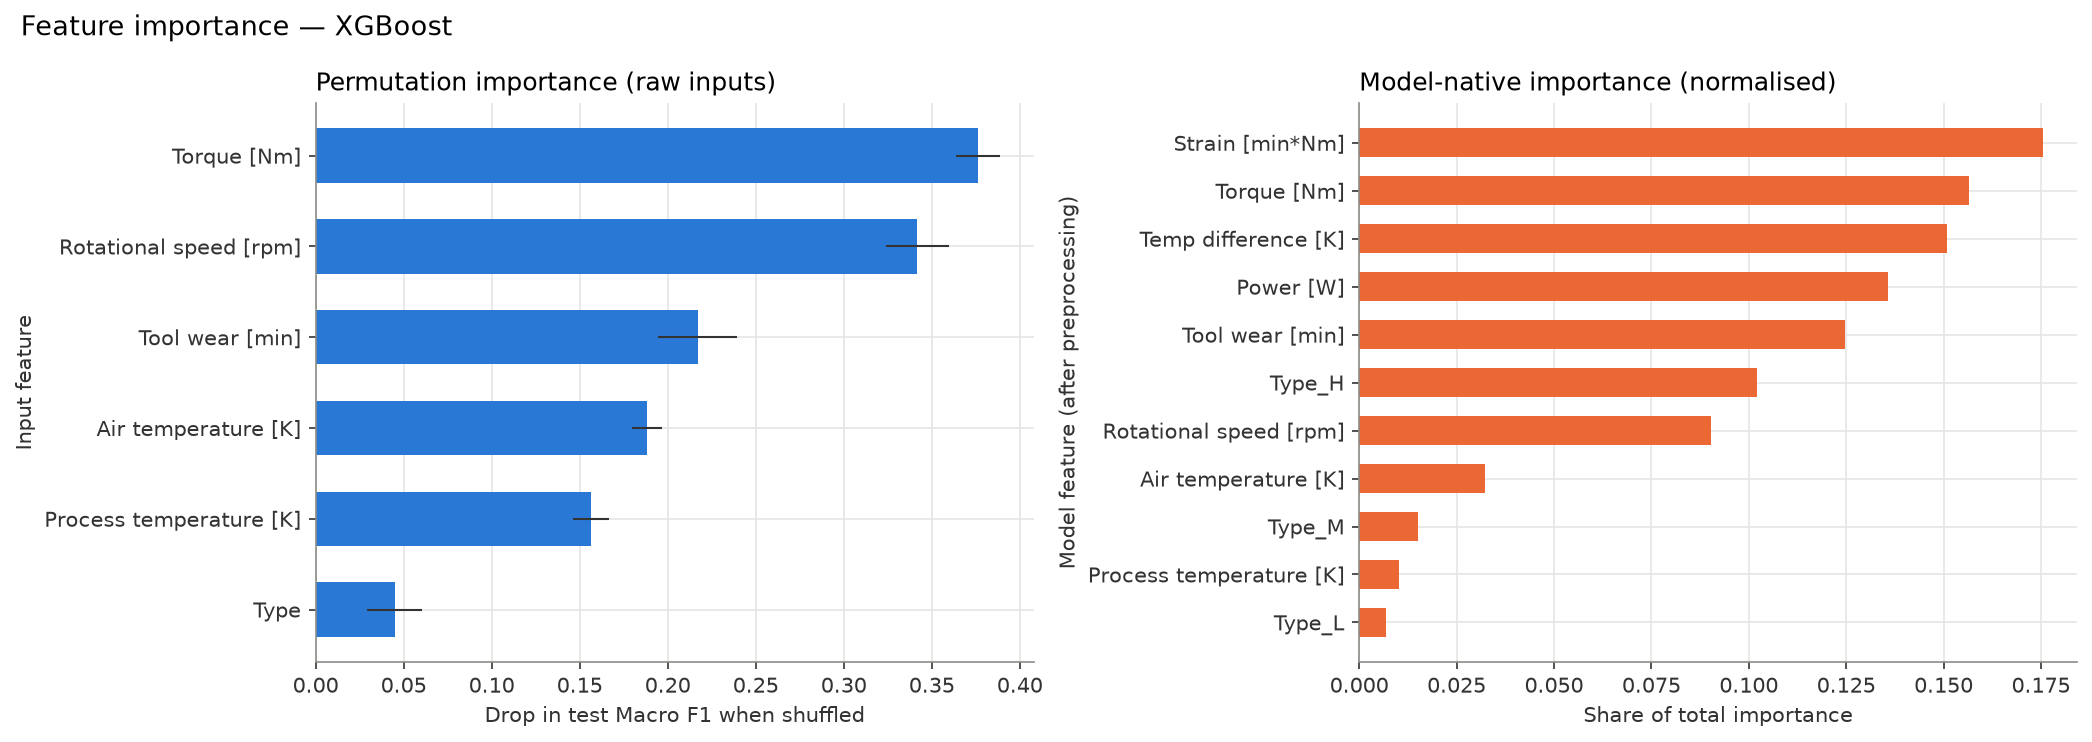

In [14]:
display(Image(filename=str(FIG / 'feature_importance.png'), width=950))

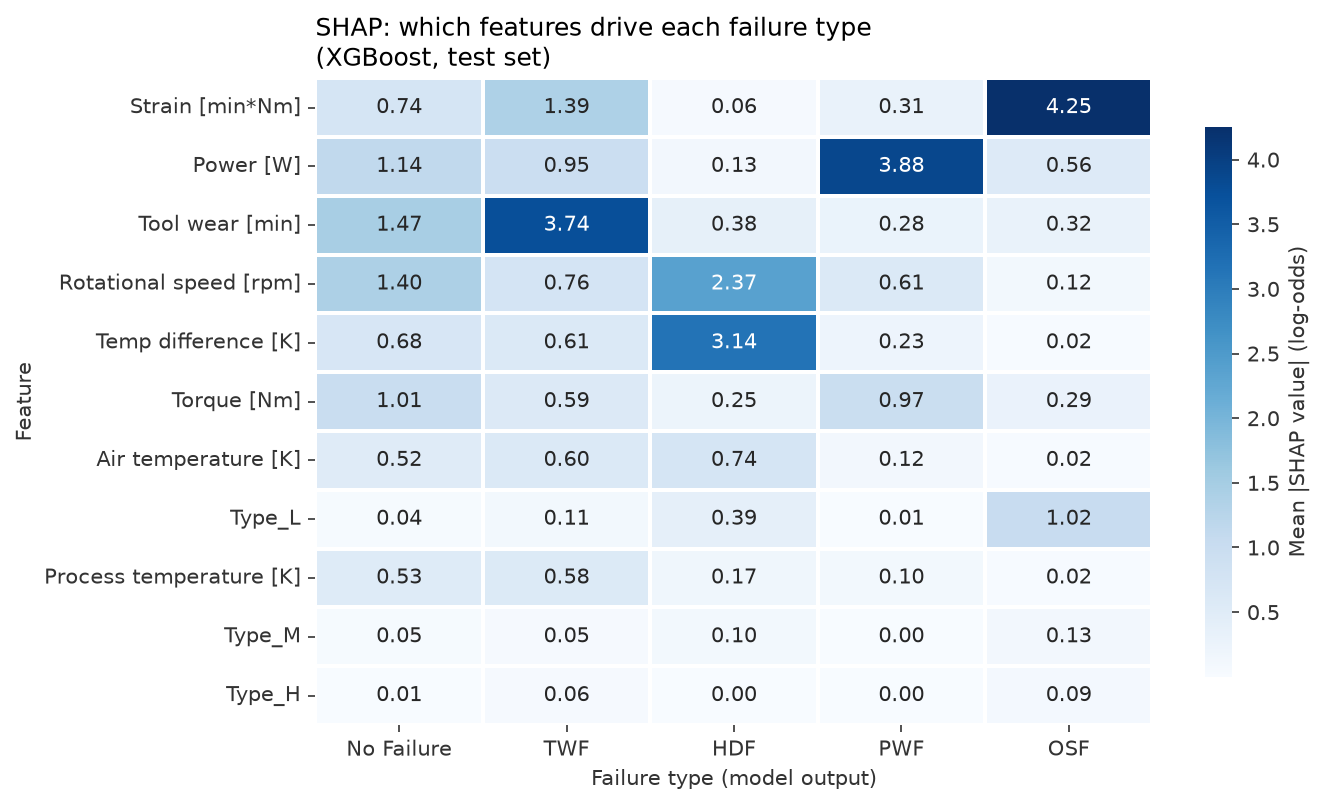

In [15]:
display(Image(filename=str(FIG / '16_shap_mean_abs_by_class.png'), width=750))

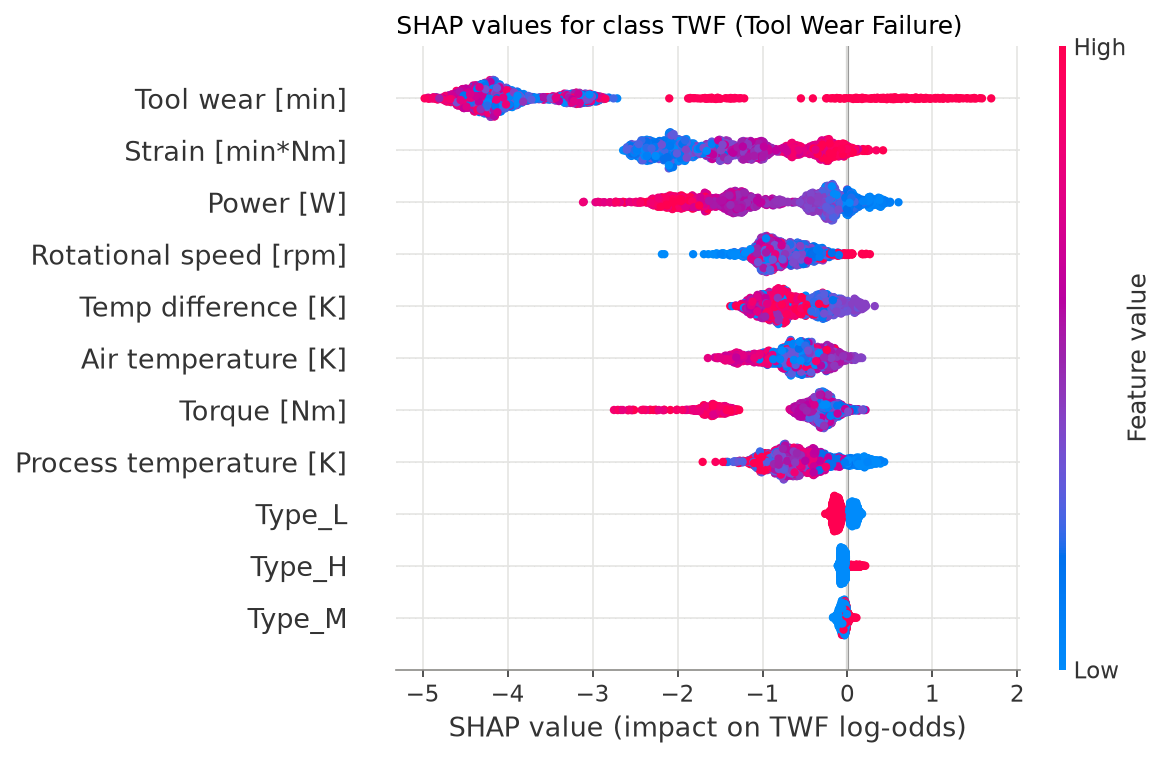

In [16]:
display(Image(filename=str(FIG / '16_shap_beeswarm_TWF.png'), width=650))

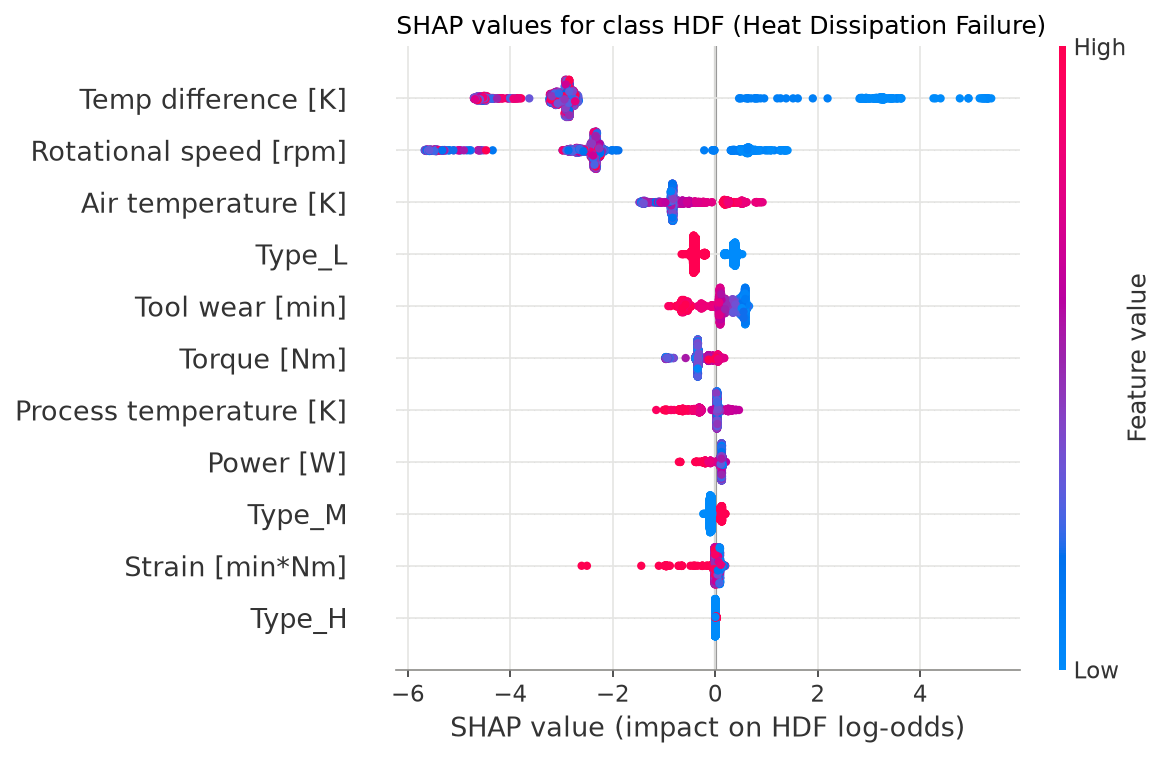

In [17]:
display(Image(filename=str(FIG / '16_shap_beeswarm_HDF.png'), width=650))

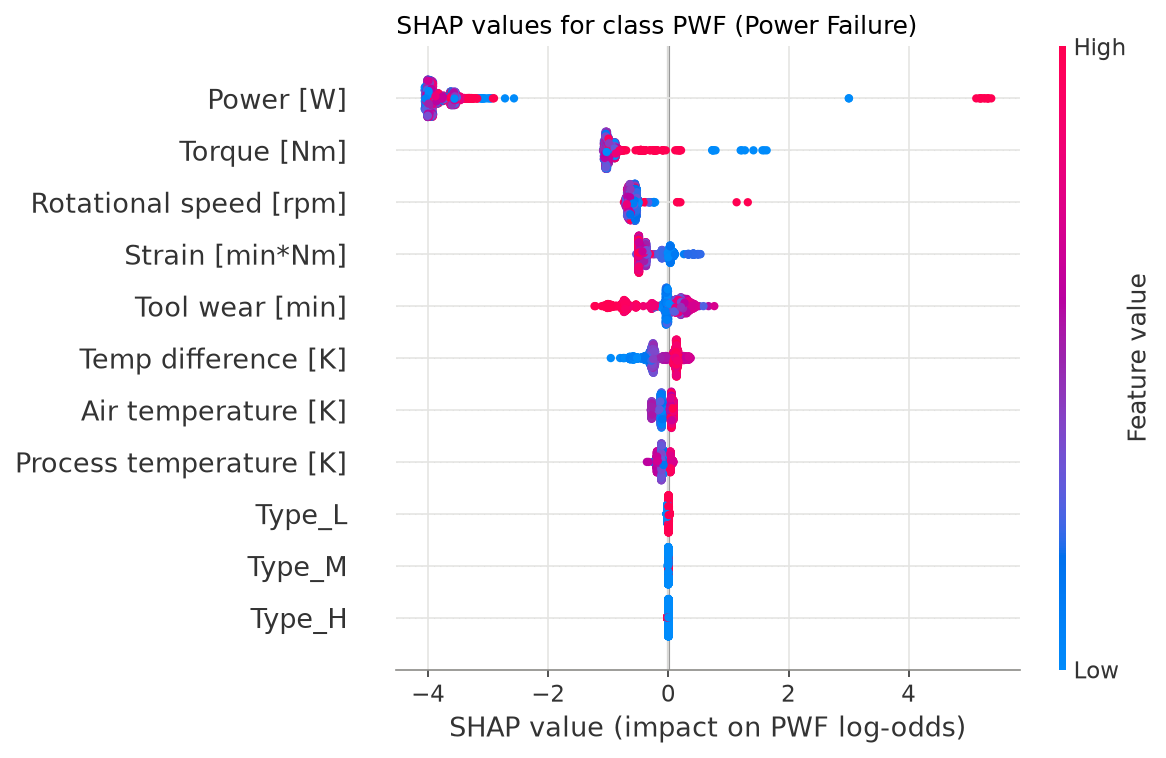

In [18]:
display(Image(filename=str(FIG / '16_shap_beeswarm_PWF.png'), width=650))

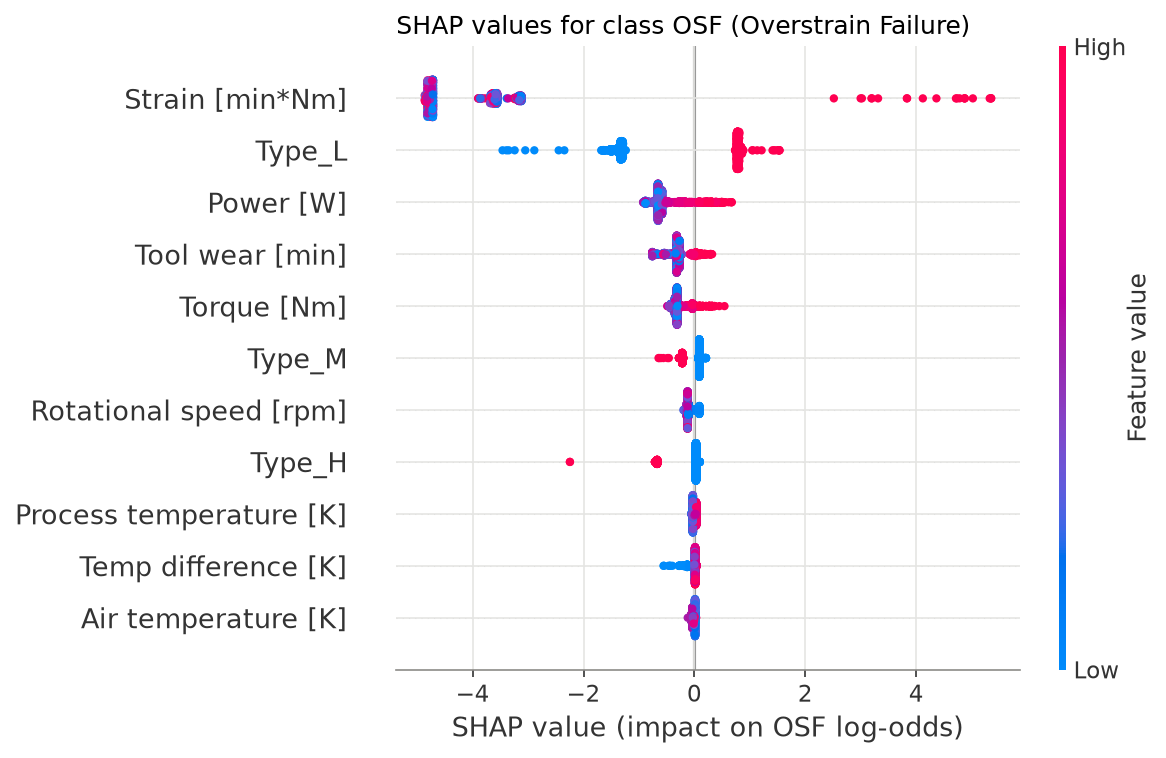

In [19]:
display(Image(filename=str(FIG / '16_shap_beeswarm_OSF.png'), width=650))

## Stage 17 — saved pipeline: reload and predict

In [20]:
from src.inference import load_artifacts, predict
pipeline, meta = load_artifacts()
print(meta['model_name'], '| steps:', list(pipeline.named_steps))
sample = {'Type': 'L', 'Air temperature [K]': 302.5, 'Process temperature [K]': 310.6,
          'Rotational speed [rpm]': 1330, 'Torque [Nm]': 52.0, 'Tool wear [min]': 90}
label, proba = predict(pipeline, sample)
print('Predicted:', label)
proba

XGBoost | steps: ['features', 'preprocess', 'model']
Predicted: HDF


,Failure type,Probability
0,HDF,9.999071e-01
1,No Failure,8.809652e-05
2,OSF,2.630468e-06
3,PWF,1.831247e-06
4,TWF,2.861518e-07
